# 03 — Cross-Validation & Fold-wise Standardization

Demonstrates v2 §4 (5-fold rolling-origin with continuous test windows), §4.1 (adaptive boundary-gap quarantine), and §5 (fold-wise standardization).

**Two standardizer variants are compared**:
- `FoldStandardizer` — pooled stats over Morocco cells, applied uniformly. **Default for v1 (global model)**.
- `PerCellStandardizer` — per-cell stats over Morocco cells only; non-Morocco cells pass through unchanged. **For per-cell sensitivity test (v2 §7.2)**.

Both use the same Morocco shapefile mask (`shapefiles/MAR_adm0.shp`, 164 cells) for stat computation, consistent with the Morocco-only modeling scope of v2.

Figures saved to `results/figures/03_cv/`.

In [1]:
%load_ext autoreload
%autoreload 2

import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch
import seaborn as sns

sns.set_theme(context='notebook', style='whitegrid')

from droughtmodel import data as ddata
from droughtmodel import features as dfeat
from droughtmodel import cv as dcv
from droughtmodel.utils import save_figure

FIG_SUBDIR = '03_cv'

data_cfg = ddata.load_config(ROOT / 'configs' / 'data.yaml')
feat_cfg = dfeat.load_features_config(ROOT / 'configs' / 'features.yaml')
cv_cfg = dcv.load_cv_config(ROOT / 'configs' / 'cv.yaml')
datasets = ddata.load_all(data_cfg)

# Build the Morocco mask once. Used everywhere from Phase 3 onward.
template = dfeat.gather_predictor('spei3', datasets)
morocco_mask = dfeat.load_region_mask(feat_cfg['region_mask']['path'], template, name='morocco')
print(f"Morocco mask: {int(morocco_mask.sum())} of {morocco_mask.size} cells ({100*float(morocco_mask.mean()):.1f}%)")

cv = dcv.RollingOriginCV.from_config(cv_cfg)
print(f"{cv.n_folds}-fold rolling-origin CV; fixed gap = {cv.fixed_gap} (None = adaptive)")
print(f"Standardization exceptions: {cv_cfg['standardization_exceptions']}")

/opt/anaconda3/envs/droughtforecast/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Morocco mask: 164 of 4096 cells (4.0%)
5-fold rolling-origin CV; fixed gap = None (None = adaptive)
Standardization exceptions: ['enso', 'nao', 'mo', 'spei3', 'target']


## 1. Fold structure with adaptive boundary gap

Run PACF + winter-only CCF on each fold's planned training window (Morocco mask) to determine `max_lag`, then use that as the boundary gap for the fold.

In [2]:
def per_fold_max_lag(fold_spec):
    """Subset raw datasets to the fold's planned train window, run lag selection, return max(lag)."""
    train_end = fold_spec.val_start - pd.Timedelta(days=1)
    train_subset = {
        k: ds.sel(time=slice(fold_spec.train_start, train_end))
        for k, ds in datasets.items()
    }
    selected, _ = dfeat.select_lags_from_training(
        train_subset,
        long_memory_vars=feat_cfg['long_memory_vars'],
        fast_response_vars=feat_cfg['fast_response_vars'],
        pacf_threshold=feat_cfg['pacf']['threshold'],
        pacf_n_lags=feat_cfg['pacf']['n_lags'],
        ccf_target=feat_cfg['ccf']['target'],
        ccf_threshold=feat_cfg['ccf']['threshold'],
        ccf_max_lag=feat_cfg['ccf']['max_lag'],
        region_mask=morocco_mask,
        winter_only_ccf=True,
        aggregation_mode='spatial_mean',
    )
    flat = [k for lags in selected.values() for k in lags]
    return max(flat) if flat else 0, selected

time_coord = template['time']
fold_records = []
for spec in cv.fold_specs:
    L, selected = per_fold_max_lag(spec)
    idx = cv.get_fold_indices(time_coord, spec, max_lag=L)
    fold_records.append({'fold_indices': idx, 'selected_lags': selected})

rows = []
for r in fold_records:
    fi = r['fold_indices']
    rows.append({
        'fold': fi.index,
        'train_start': fi.train_start.strftime('%Y-%m'),
        'train_end (post-quarantine)': fi.train_end.strftime('%Y-%m'),
        'val_start': fi.val_start.strftime('%Y-%m'),
        'val_end (post-quarantine)': fi.val_end.strftime('%Y-%m'),
        'test_start': fi.test_start.strftime('%Y-%m'),
        'test_end': fi.test_end.strftime('%Y-%m'),
        'max_lag (adaptive)': fi.boundary_gap,
        '#train (mo)': fi.n_train,
        '#val (mo)': fi.n_val,
        '#test (mo)': fi.n_test,
        '#test winter (mo)': int(fi.winter_mask(time_coord).sum()),
    })
summary = pd.DataFrame(rows)
summary

,fold,train_start,train_end (post-quarantine),val_start,val_end (post-quarantine),test_start,test_end,max_lag (adaptive),#train (mo),#val (mo),#test (mo),#test winter (mo)
0,1,1950-01,1990-12,1992-01,1998-12,2000-01,2004-12,12,492,84,60,20
1,2,1950-01,1995-12,1997-01,2003-12,2005-01,2009-12,12,552,84,60,20
2,3,1950-01,2000-12,2002-01,2008-12,2010-01,2014-12,12,612,84,60,20
3,4,1950-01,2005-12,2007-01,2013-12,2015-01,2019-12,12,672,84,60,20
4,5,1950-01,2010-12,2012-01,2018-12,2020-01,2024-12,12,732,84,60,20


## 2. Gantt chart of train / val / test / quarantine spans

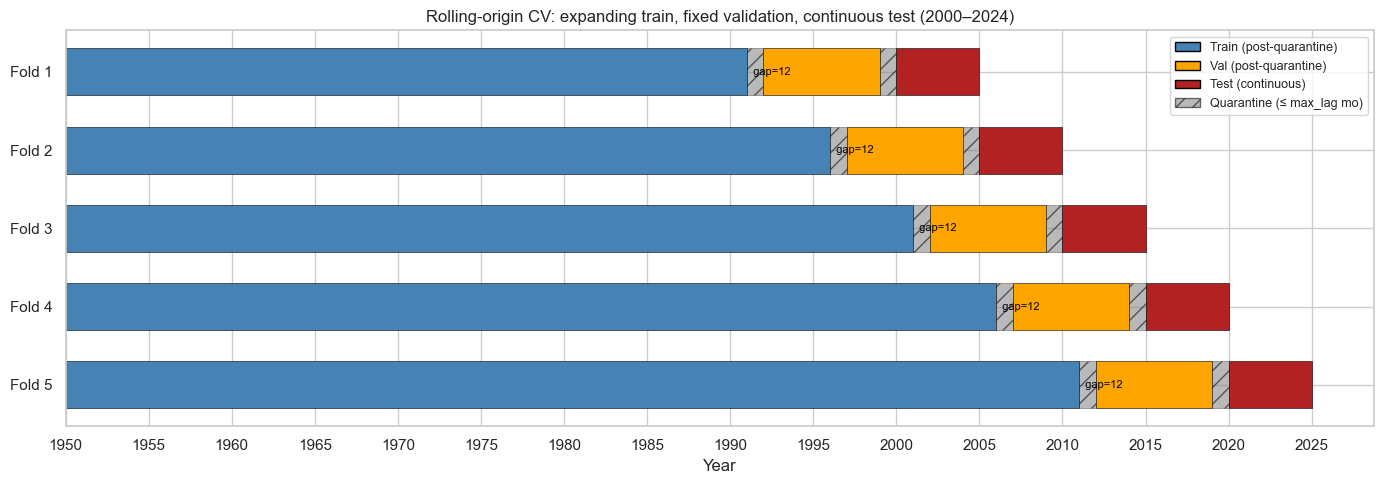

In [11]:
fig, ax = plt.subplots(figsize=(14, 5))

color_train = 'steelblue'
color_val = 'orange'
color_test = 'firebrick'
color_quarantine = 'gray'

month = pd.DateOffset(months=1)
for r in fold_records:
    fi = r['fold_indices']
    y = cv.n_folds - fi.index + 1
    ax.barh(y, fi.train_end + month - fi.train_start, left=fi.train_start, height=0.6,
            color=color_train, edgecolor='black', linewidth=0.4)
    q1_start = fi.train_end + month
    q1_end = fi.val_start
    if q1_end > q1_start:
        ax.barh(y, q1_end - q1_start, left=q1_start, height=0.6,
                color=color_quarantine, alpha=0.55, hatch='//', edgecolor='black', linewidth=0.4)
    ax.barh(y, fi.val_end + month - fi.val_start, left=fi.val_start, height=0.6,
            color=color_val, edgecolor='black', linewidth=0.4)
    q2_start = fi.val_end + month
    q2_end = fi.test_start
    if q2_end > q2_start:
        ax.barh(y, q2_end - q2_start, left=q2_start, height=0.6,
                color=color_quarantine, alpha=0.55, hatch='//', edgecolor='black', linewidth=0.4)
    ax.barh(y, fi.test_end + month - fi.test_start, left=fi.test_start, height=0.6,
            color=color_test, edgecolor='black', linewidth=0.4)
    ax.text(fi.train_end + month, y, f'  gap={fi.boundary_gap}',
            va='center', fontsize=8, color='black')

legend_handles = [
    Patch(facecolor=color_train, edgecolor='black', label='Train (post-quarantine)'),
    Patch(facecolor=color_val, edgecolor='black', label='Val (post-quarantine)'),
    Patch(facecolor=color_test, edgecolor='black', label='Test (continuous)'),
    Patch(facecolor=color_quarantine, edgecolor='black', alpha=0.55, hatch='//', label='Quarantine (≤ max_lag mo)'),
]
ax.legend(handles=legend_handles, loc='upper right', fontsize=9)
ax.set_yticks(range(1, cv.n_folds + 1))
ax.set_yticklabels([f'Fold {cv.n_folds - i + 1}' for i in range(1, cv.n_folds + 1)])
ax.set_xlabel('Year')
ax.set_title('Rolling-origin CV: expanding train, fixed validation, continuous test (2000–2024)')
ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.xaxis.set_minor_locator(mdates.YearLocator(1))
plt.tight_layout()
save_figure(fig, 'fold_structure_gantt', subdir=FIG_SUBDIR)
plt.show()

## 3. Continuous-test verification

In [4]:
all_test_idx = np.concatenate([r['fold_indices'].test_idx for r in fold_records])
diffs = np.diff(all_test_idx)
first_ts = pd.Timestamp(time_coord.values[all_test_idx[0]])
last_ts = pd.Timestamp(time_coord.values[all_test_idx[-1]])
winter_pooled = int(np.isin(pd.DatetimeIndex(time_coord.values[all_test_idx]).month, [11,12,1,2]).sum())
print(f'Pooled test array: {len(all_test_idx)} months from {first_ts:%Y-%m} to {last_ts:%Y-%m}')
print(f'  Index-diff range (should all be 1): min={diffs.min()}, max={diffs.max()}')
print(f'  Pooled winter months (Nov–Feb): {winter_pooled}')

Pooled test array: 300 months from 2000-01 to 2024-12
  Index-diff range (should all be 1): min=1, max=1
  Pooled winter months (Nov–Feb): 100


## 4. Build a sample feature dataset (L = 3, fold 1 lags)

In [5]:
lead = 3
selected_lags_f1 = fold_records[0]['selected_lags']
fi1 = fold_records[0]['fold_indices']

ds_L3 = dfeat.build_dataset(
    datasets, lead=lead,
    contemporary=feat_cfg['contemporary_predictors'],
    lags=selected_lags_f1,
    include_seasonal=feat_cfg['include_seasonal_encoding'],
    include_spatial=feat_cfg['include_spatial_encoding'],
)

train_ds = ds_L3.isel(time=fi1.train_idx)
val_ds = ds_L3.isel(time=fi1.val_idx)
test_ds = ds_L3.isel(time=fi1.test_idx)

print(f'Dataset for L={lead}: {len(ds_L3.data_vars)-1} features + target')
print(f'Train: {fi1.n_train} months ({fi1.train_start:%Y-%m}..{fi1.train_end:%Y-%m})')
print(f'Val:   {fi1.n_val} months ({fi1.val_start:%Y-%m}..{fi1.val_end:%Y-%m})')
print(f'Test:  {fi1.n_test} months ({fi1.test_start:%Y-%m}..{fi1.test_end:%Y-%m})')

Dataset for L=3: 57 features + target
Train: 492 months (1950-01..1990-12)
Val:   84 months (1992-01..1998-12)
Test:  60 months (2000-01..2004-12)


## 5. Standardizer A — `FoldStandardizer` (global / pooled, Morocco-masked)

Stats are computed pooled across (time, Morocco cells). One scalar (μ, σ) per variable. The model receives standardized features at every cell; spatial heterogeneity is preserved as differing z-score ranges between cells (so the global model can learn from (lat, lon) features).

In [6]:
std_pooled = dcv.FoldStandardizer.from_config(cv_cfg, region_mask=morocco_mask)
std_pooled.fit(train_ds)
train_pooled = std_pooled.transform(train_ds)

# Compare WITH vs WITHOUT mask to show the difference the Morocco mask makes.
std_unmasked = dcv.FoldStandardizer.from_config(cv_cfg).fit(train_ds)  # no region_mask

compare_rows = []
for var in ['precip', 'tmin', 'tmax', 'pet', 'rzsm', 'tcwv', 'vpd', 'wind', 'solar']:
    if var not in train_ds.data_vars:
        continue
    u = std_unmasked.stats.get(var, (np.nan, np.nan))
    m = std_pooled.stats.get(var, (np.nan, np.nan))
    compare_rows.append({
        'variable': var,
        'unmasked μ': round(u[0], 3), 'unmasked σ': round(u[1], 3),
        'Morocco-only μ': round(m[0], 3), 'Morocco-only σ': round(m[1], 3),
        'Δμ (mask−unmasked)': round(m[0] - u[0], 3),
    })
pd.DataFrame(compare_rows)

,variable,unmasked μ,unmasked σ,Morocco-only μ,Morocco-only σ,Δμ (mask−unmasked)
0,precip,22.989,39.383,28.196,36.717,5.208
1,tmin,15.361,8.115,11.472,6.184,-3.888
2,tmax,28.017,9.853,23.348,6.915,-4.669
3,pet,4.493,1.992,3.789,1.636,-0.704
4,rzsm,0.055,0.100,0.169,0.085,0.114
5,tcwv,18.019,6.561,14.093,4.767,-3.926
6,vpd,12.358,12.848,11.570,9.328,-0.789
7,wind,4.055,1.502,2.309,0.830,-1.746
8,solar,220.768,78.145,237.641,70.324,16.874


## 6. Standardizer B — `PerCellStandardizer` (per-cell, Morocco-restricted)

For Morocco cells: one (μ, σ) per (lat, lon), computed from that cell's training-period time series. For cells outside Morocco: μ=0, σ=1 (identity transform — values pass through unchanged so the downstream pipeline can ignore them). Used for the per-cell modeling sensitivity test.

In [7]:
std_percell = dcv.PerCellStandardizer.from_config(cv_cfg, region_mask=morocco_mask)
std_percell.fit(train_ds)
train_percell = std_percell.transform(train_ds)

# Verify behavior of percell standardization
checks = []
for var in ['precip', 'rzsm', 'tcwv']:
    cell_mu = train_percell[var].mean(dim='time').values
    cell_sigma = train_percell[var].std(dim='time').values
    inside = cell_mu[morocco_mask.values]
    outside = cell_mu[~morocco_mask.values]
    inside_s = cell_sigma[morocco_mask.values]
    outside_s = cell_sigma[~morocco_mask.values]
    # Drop NaN for outside (just-in-case)
    outside = outside[np.isfinite(outside)]
    outside_s = outside_s[np.isfinite(outside_s)]
    checks.append({
        'variable': var,
        'Morocco cells (μ_t range)': f'[{inside.min():+.4f}, {inside.max():+.4f}]',
        'Morocco cells (σ_t range)': f'[{inside_s.min():.4f}, {inside_s.max():.4f}]',
        'Outside cells (μ_t range)': f'[{outside.min():+.2f}, {outside.max():+.2f}]',
        'Outside cells (σ_t range)': f'[{outside_s.min():.2f}, {outside_s.max():.2f}]',
    })
print('Per-cell time-mean and time-std across Morocco vs outside cells:')
pd.DataFrame(checks)

Per-cell time-mean and time-std across Morocco vs outside cells:


,variable,Morocco cells (μ_t range),Morocco cells (σ_t range),Outside cells (μ_t range),Outside cells (σ_t range)
0,precip,"[-0.0000, +0.0000]","[1.0000, 1.0000]","[+0.71, +150.27]","[0.96, 124.43]"
1,rzsm,"[-0.0000, +0.0000]","[1.0000, 1.0000]","[+0.00, +0.44]","[0.00, 0.08]"
2,tcwv,"[-0.0000, +0.0000]","[1.0000, 1.0000]","[+7.11, +28.66]","[2.87, 12.92]"


## 7. Side-by-side comparison — spatial maps before / after standardization

Top row: raw precip mean over the training period. Middle row: after `FoldStandardizer` (pooled, Morocco-masked stats). Bottom row: after `PerCellStandardizer` (per-cell, Morocco-restricted).

Key visual distinctions:
- **FoldStandardizer**: every Morocco cell has a non-zero z-score reflecting its position in the regional distribution (Atlas wetter than coast wetter than south). Spatial heterogeneity is preserved.
- **PerCellStandardizer**: every Morocco cell has time-mean ≈ 0. Spatial heterogeneity is removed (all cells look the same). Cells outside Morocco retain raw values (pass-through).


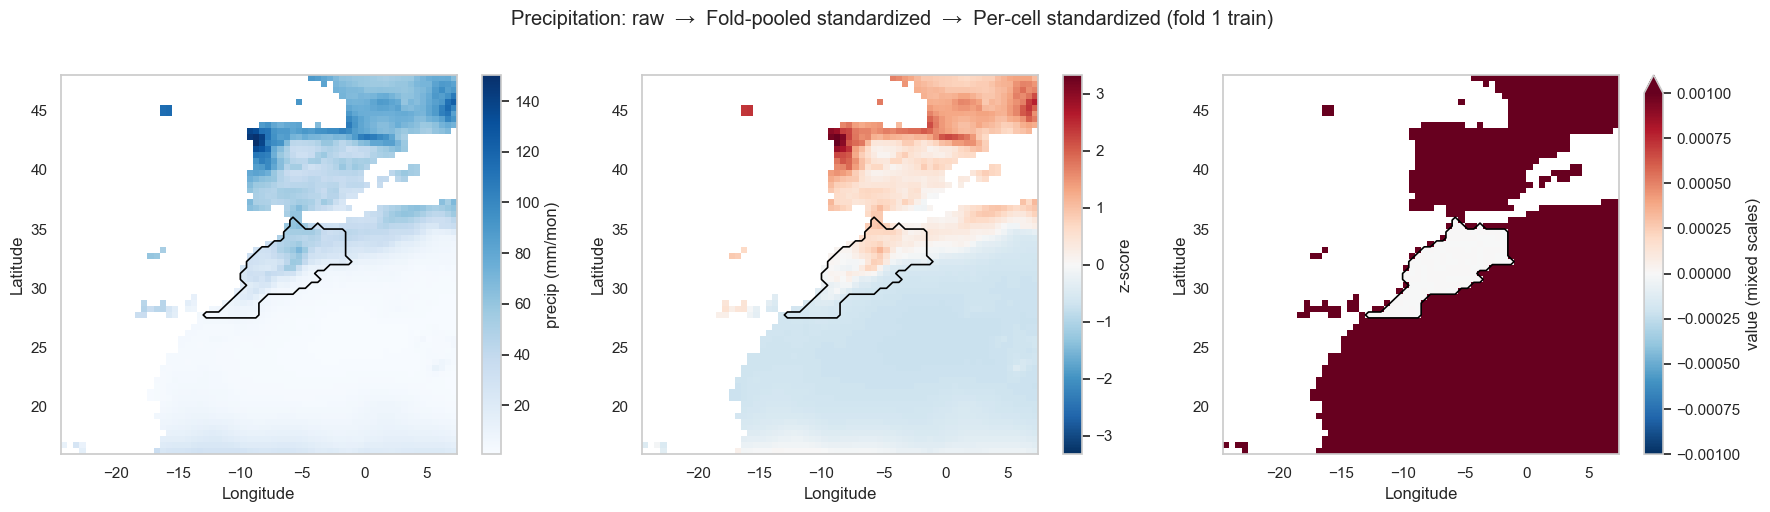

In [8]:
import matplotlib.colors as mcolors

def time_mean(da):
    return da.mean(dim='time', skipna=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw precip mean
raw_mean = time_mean(train_ds['precip'])
im0 = raw_mean.plot(ax=axes[0], cmap='Blues', cbar_kwargs={'label': 'precip (mm/mon)'})
axes[0].set_title('Raw precip — time mean')

# After pooled standardization (FoldStandardizer)
pooled_mean = time_mean(train_pooled['precip'])
vmax_p = float(np.nanmax(np.abs(pooled_mean.values)))
pooled_mean.plot(ax=axes[1], cmap='RdBu_r', vmin=-vmax_p, vmax=vmax_p, cbar_kwargs={'label': 'z-score'})
axes[1].set_title('After FoldStandardizer (pooled, Morocco-masked stats)')

# After per-cell standardization (PerCellStandardizer)
percell_mean = time_mean(train_percell['precip'])
# Outside Morocco shows raw values (in mm/mon), inside shows z-score (~0). Use a divergent symmetric colormap
# limited to inside-Morocco range so Morocco signal is visible.
inside_vals = percell_mean.where(morocco_mask).values
vmax_c = max(float(np.nanmax(np.abs(inside_vals))), 0.001)
percell_mean.plot(ax=axes[2], cmap='RdBu_r', vmin=-vmax_c, vmax=vmax_c, cbar_kwargs={'label': 'value (mixed scales)'})
axes[2].set_title('After PerCellStandardizer (per-cell, Morocco only)')

# Outline Morocco on all subplots
import matplotlib.patheffects as path_effects
for ax in axes:
    morocco_mask.plot.contour(ax=ax, levels=[0.5], colors='black', linewidths=1.2, add_colorbar=False)
    ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')

fig.suptitle('Precipitation: raw  →  Fold-pooled standardized  →  Per-cell standardized (fold 1 train)', y=1.02)
plt.tight_layout()
save_figure(fig, 'precip_standardization_comparison', subdir=FIG_SUBDIR)
plt.show()

## 8. Time-series view at a single Morocco cell

Compare how a representative Moroccan cell (Marrakech-ish) looks under both transforms. The shapes are identical (linear transformation per cell preserves shape), but the scales differ.

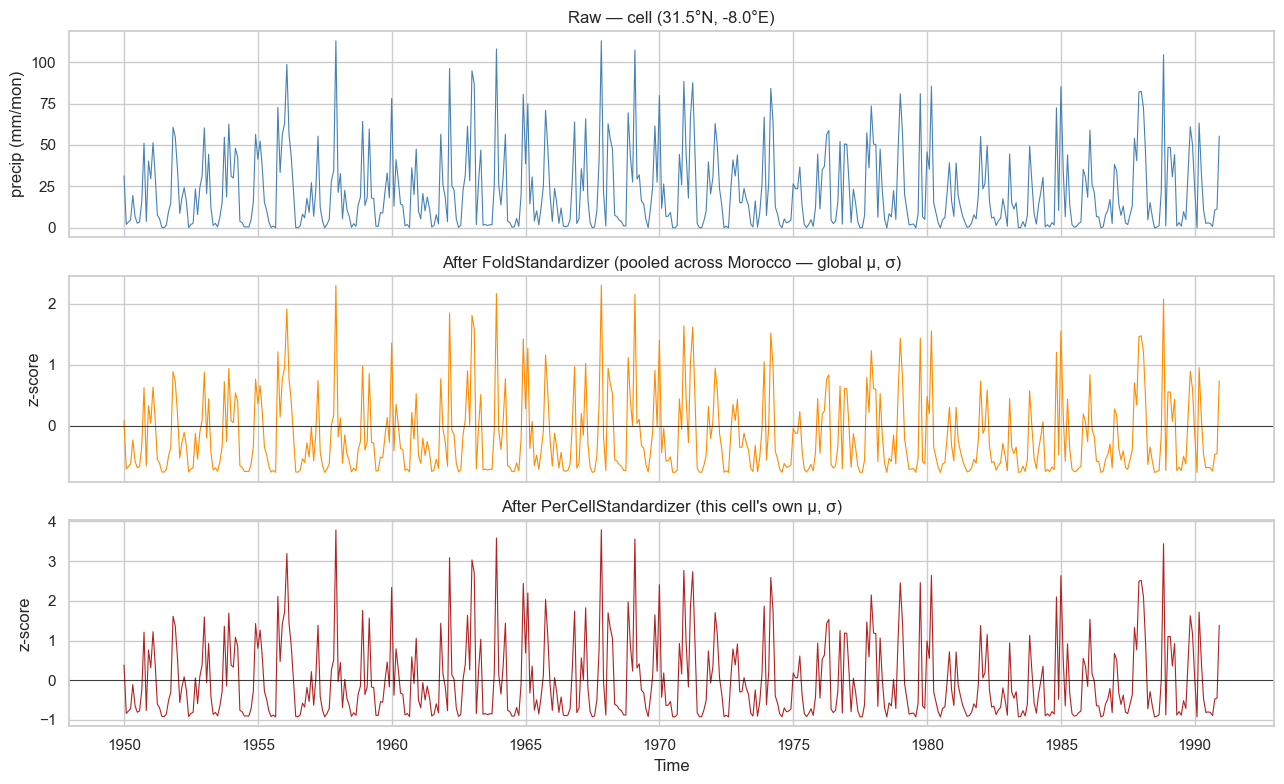

Cell statistics (training period):
  raw:     μ = 22.133 mm/mon, σ = 23.947
  pooled:  μ = -0.1651,     σ = 0.652
  percell: μ = +0.0000,     σ = 1.000


In [9]:
cell_lat, cell_lon = 31.5, -8.0

fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)

raw_ts = train_ds['precip'].sel(lat=cell_lat, lon=cell_lon, method='nearest')
axes[0].plot(raw_ts.time, raw_ts.values, color='steelblue', linewidth=0.8)
axes[0].set_ylabel('precip (mm/mon)')
axes[0].set_title(f'Raw — cell ({cell_lat:.1f}°N, {cell_lon:.1f}°E)')

pooled_ts = train_pooled['precip'].sel(lat=cell_lat, lon=cell_lon, method='nearest')
axes[1].plot(pooled_ts.time, pooled_ts.values, color='darkorange', linewidth=0.8)
axes[1].axhline(0, color='black', linewidth=0.5)
axes[1].set_ylabel('z-score')
axes[1].set_title('After FoldStandardizer (pooled across Morocco — global μ, σ)')

percell_ts = train_percell['precip'].sel(lat=cell_lat, lon=cell_lon, method='nearest')
axes[2].plot(percell_ts.time, percell_ts.values, color='firebrick', linewidth=0.8)
axes[2].axhline(0, color='black', linewidth=0.5)
axes[2].set_ylabel('z-score')
axes[2].set_title('After PerCellStandardizer (this cell\'s own μ, σ)')
axes[2].set_xlabel('Time')

plt.tight_layout()
save_figure(fig, 'cell_timeseries_comparison', subdir=FIG_SUBDIR)
plt.show()

print(f"Cell statistics (training period):")
print(f"  raw:     μ = {float(raw_ts.mean()):.3f} mm/mon, σ = {float(raw_ts.std()):.3f}")
print(f"  pooled:  μ = {float(pooled_ts.mean()):+.4f},     σ = {float(pooled_ts.std()):.3f}")
print(f"  percell: μ = {float(percell_ts.mean()):+.4f},     σ = {float(percell_ts.std()):.3f}")

## 9. Exception list — both standardizers leave ENSO/NAO/MO/SPEI3/target unchanged

In [10]:
exception_check = []
for var in cv_cfg['standardization_exceptions']:
    if var not in train_ds.data_vars:
        continue
    pre = train_ds[var].values
    post_pooled = train_pooled[var].values
    post_percell = train_percell[var].values
    unchanged_pooled = bool(np.array_equal(pre, post_pooled, equal_nan=True))
    unchanged_percell = bool(np.array_equal(pre, post_percell, equal_nan=True))
    exception_check.append({
        'variable': var,
        'unchanged by pooled':  unchanged_pooled,
        'unchanged by percell': unchanged_percell,
    })
# Also check a couple of _lag variants if present
for var in ['enso_lag1', 'mo_lag2', 'spei3_lag1']:
    if var not in train_ds.data_vars:
        continue
    pre = train_ds[var].values
    post_pooled = train_pooled[var].values
    post_percell = train_percell[var].values
    exception_check.append({
        'variable': var + ' (lag)',
        'unchanged by pooled':  bool(np.array_equal(pre, post_pooled, equal_nan=True)),
        'unchanged by percell': bool(np.array_equal(pre, post_percell, equal_nan=True)),
    })
pd.DataFrame(exception_check)

,variable,unchanged by pooled,unchanged by percell
0,enso,True,True
1,nao,True,True
2,mo,True,True
3,spei3,True,True
4,target,True,True
5,enso_lag1 (lag),True,True
6,mo_lag2 (lag),True,True
7,spei3_lag1 (lag),True,True


## Notes — implications for global vs per-cell modeling

**Global model (v1 default)**:
- Uses `FoldStandardizer` with `region_mask=morocco_mask`
- Stats are pooled across Morocco cells (Saharan distortion removed)
- Spatial heterogeneity is preserved in z-space — the model uses `lat_feat` / `lon_feat` features to learn cell-specific behavior
- Single model fits all Morocco cells

**Per-cell model (sensitivity test, v2 §7.2)**:
- Uses `PerCellStandardizer` with `region_mask=morocco_mask`
- Each Morocco cell normalized to (μ=0, σ=1) over its own time history
- Spatial heterogeneity is removed — every cell expresses pure within-cell anomalies
- `(lat, lon)` features should be DROPPED — they are constants within a cell, so zero-variance for that cell's model. Set `features.yaml::include_spatial_encoding: false` for per-cell experiments.
- One model trained per Morocco cell (164 models)

**Shared properties**:
- Exception list (`ENSO`, `NAO`, `MO`, `SPEI3`, `target`, and `*_lag*` variants) bypasses both standardizers — already in z-score units.
- Both standardizers fit on TRAIN ONLY; val and test transformed with train stats (no leakage).
- Both restrict stat computation to Morocco cells via `region_mask`, consistent with the Morocco-only modeling scope (Phase 3 onward).

**The pipeline (Phase 10)** will pick one of the two standardizers via the experiment YAML (`modeling_unit: global` → FoldStandardizer; `modeling_unit: per_cell` → PerCellStandardizer + `include_spatial_encoding: false`).